Input: Dataset D, model θ, learning rate η,
       clipping norm C, noise σ, epochs E

For each epoch:
    For each batch B:

        1. Compute per-sample gradients:
           gi = ∇θ L(θ, xi)

        2. Clip gradients:
           gi ← gi / max(1, ||gi|| / C)

        3. Average gradients:
           g = (1 / |B|) Σ gi

        4. Add Gaussian noise:
           g̃ = g + N(0, σ²C²)

        5. Update model:
           θ ← θ - η * g̃

Compute gradients → Clip → Add noise → Update model

[Baseline] Epoch 1 | Accuracy: 96.11%
[Baseline] Epoch 2 | Accuracy: 97.14%
[Baseline] Epoch 3 | Accuracy: 97.15%
[DP σ=0.5] Epoch 1 | Accuracy: 88.67% | ε: 0.2216
[DP σ=0.5] Epoch 2 | Accuracy: 89.90% | ε: 0.3134
[DP σ=0.5] Epoch 3 | Accuracy: 90.39% | ε: 0.3839
[DP σ=1.0] Epoch 1 | Accuracy: 86.58% | ε: 0.1108
[DP σ=1.0] Epoch 2 | Accuracy: 87.80% | ε: 0.1567
[DP σ=1.0] Epoch 3 | Accuracy: 88.21% | ε: 0.1919
[DP σ=2.0] Epoch 1 | Accuracy: 80.24% | ε: 0.0554
[DP σ=2.0] Epoch 2 | Accuracy: 79.09% | ε: 0.0784
[DP σ=2.0] Epoch 3 | Accuracy: 79.12% | ε: 0.0960


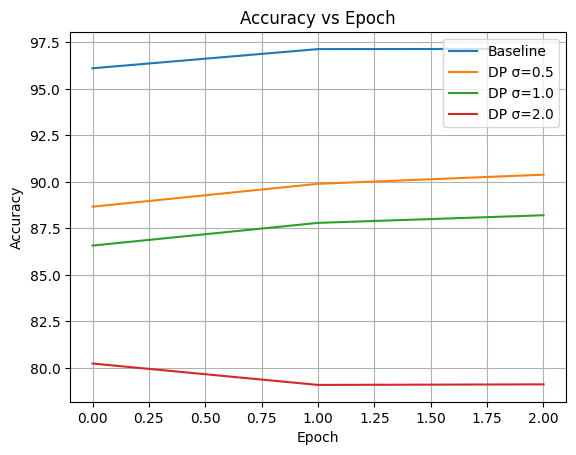

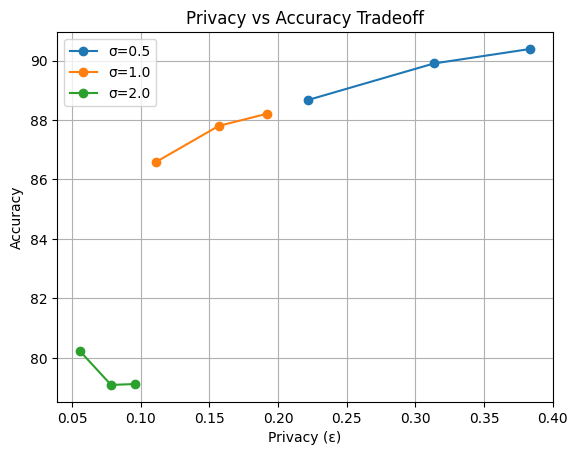

In [1]:

# =========================================================
# DP-SGD
# =========================================================

import torch
import torch.nn as nn
from torchvision import datasets, transforms
import math
import matplotlib.pyplot as plt
from PIL import Image


# =========================================================
# CONFIGURATION CLASS
# =========================================================
class Config:
    """ 
    This class stores all hyperparameters and settings
    Used to easily modify experiments
    """
    DATA_PATH = "./data"                 # Dataset storage location
    BATCH_SIZE = 32                      # Number of samples per batch
    TEST_BATCH_SIZE = 64                 # Batch size for testing
    LEARNING_RATE = 0.05                 # Step size for weight update
    CLIP_NORM = 1.0                      # Maximum gradient norm (C in paper)
    NOISE_MULTIPLIERS = [0.5, 1.0, 2.0]  # Different privacy levels (σ)
    EPOCHS = 3                           # Number of training iterations
    DELTA = 1e-5                         # Probability of privacy failure
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =========================================================
# DATA LOADER CLASS
# =========================================================
class MNISTLoader:
    """
    Loads MNIST dataset and prepares DataLoaders
    """

    def __init__(self, config):
        self.config = config

        # Normalize data for better training
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])

    def get_loaders(self):
        # Load training data
        train_dataset = datasets.MNIST(
            root=self.config.DATA_PATH,
            train=True,
            download=True,
            transform=self.transform
        )

        # Load test data
        test_dataset = datasets.MNIST(
            root=self.config.DATA_PATH,
            train=False,
            download=True,
            transform=self.transform
        )

        # Convert dataset into batches
        train_loader = torch.utils.data.DataLoader(
            train_dataset,
            batch_size=self.config.BATCH_SIZE,
            shuffle=True
        )

        test_loader = torch.utils.data.DataLoader(
            test_dataset,
            batch_size=self.config.TEST_BATCH_SIZE,
            shuffle=False
        )

        return train_dataset, train_loader, test_loader


# =========================================================
# MODEL CLASS
# =========================================================
class DigitClassifier(nn.Module):
    """
    Simple Neural Network:
    Input → FC1 → ReLU → FC2 → Output
    """

    def __init__(self):
        super().__init__()

        # First fully connected layer
        # Converts 784 input pixels → 128 features
        self.fc1 = nn.Linear(28 * 28, 128)

        # Output layer
        # Converts 128 features → 10 classes (digits 0–9)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Flatten image from 28x28 → 784
        x = x.view(-1, 28 * 28)

        # Apply first layer + activation
        x = torch.relu(self.fc1(x))

        # Output layer
        return self.fc2(x)


# =========================================================
# TRAINER CLASS
# =========================================================
class DPSGDTrainer:
    """
    Implements both:
    - Normal SGD (baseline)
    - Differentially Private SGD (DP-SGD)
    """

    def __init__(self, config, train_dataset, train_loader, test_loader):
        self.config = config
        self.train_dataset = train_dataset
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.criterion = nn.CrossEntropyLoss()  # Loss function

    # -----------------------------------------------------
    # EVALUATION FUNCTION
    # -----------------------------------------------------
    def evaluate(self, model):
        """
        Computes model accuracy on test data
        """
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for data, target in self.test_loader:
                data, target = data.to(self.config.DEVICE), target.to(self.config.DEVICE)

                output = model(data)
                pred = output.argmax(dim=1)

                correct += (pred == target).sum().item()
                total += target.size(0)

        return 100 * correct / total

    # -----------------------------------------------------
    # PER-SAMPLE GRADIENTS
    # -----------------------------------------------------
    def compute_per_sample_gradients(self, model, data, target):
        """
        Computes gradient for EACH individual sample
        (Unlike normal SGD which computes batch gradient)
        """
        grads = []

        for i in range(len(data)):
            model.zero_grad(set_to_none=True)

            output = model(data[i].unsqueeze(0))
            loss = self.criterion(output, target[i].unsqueeze(0))
            loss.backward()

            # Store gradient of each parameter
            grads.append([p.grad.detach().clone() for p in model.parameters()])

        return grads

    # -----------------------------------------------------
    # GRADIENT CLIPPING
    # -----------------------------------------------------
    def clip_gradients(self, gradients):
        """
        Limits gradient magnitude to control sensitivity
        Formula: g ← g / max(1, ||g|| / C)
        """
        clipped = []

        for grad_list in gradients:
            total_norm = torch.sqrt(sum([g.norm() ** 2 for g in grad_list]))

            # Compute scaling factor
            scale = min(1.0, self.config.CLIP_NORM / (total_norm + 1e-6))

            # Apply clipping
            clipped.append([g * scale for g in grad_list])

        return clipped

    # -----------------------------------------------------
    # ADD NOISE
    # -----------------------------------------------------
    def add_noise(self, gradients, sigma):
        """
        Adds Gaussian noise to gradients
        Ensures Differential Privacy
        """
        batch_size = len(gradients)
        noisy_grads = []

        for i in range(len(gradients[0])):
            stacked = torch.stack([g[i] for g in gradients])

            # Average gradients
            avg_grad = torch.mean(stacked, dim=0)

            # Add Gaussian noise
            noise = torch.normal(
                mean=0,
                std=sigma * self.config.CLIP_NORM,
                size=avg_grad.shape,
                device=avg_grad.device
            )

            noisy_grads.append(avg_grad + noise / batch_size)

        return noisy_grads

    # -----------------------------------------------------
    # UPDATE MODEL PARAMETERS
    # -----------------------------------------------------
    def update_model(self, model, grads):
        """
        Performs manual SGD update
        θ = θ - η * gradient
        """
        with torch.no_grad():
            for p, g in zip(model.parameters(), grads):
                p -= self.config.LEARNING_RATE * g

    # -----------------------------------------------------
    # PRIVACY CALCULATION
    # -----------------------------------------------------
    def compute_epsilon(self, epoch, sigma):
        """
        Computes privacy budget ε
        
        Formula:
        ε ≈ (q * sqrt(2 * T * log(1/δ))) / σ

        where:
        q = sampling rate
        T = total steps
        σ = noise multiplier
        δ = small failure probability
        """
        q = self.config.BATCH_SIZE / len(self.train_dataset)
        T = (epoch + 1) * len(self.train_loader)

        return (q * math.sqrt(2 * T * math.log(1 / self.config.DELTA))) / sigma

    # -----------------------------------------------------
    # BASELINE TRAINING
    # -----------------------------------------------------
    def train_baseline(self):
        """
        Standard SGD training without privacy
        """
        model = DigitClassifier().to(self.config.DEVICE)
        optimizer = torch.optim.SGD(model.parameters(), lr=self.config.LEARNING_RATE)

        acc_history = []

        for epoch in range(self.config.EPOCHS):
            model.train()

            for data, target in self.train_loader:
                data, target = data.to(self.config.DEVICE), target.to(self.config.DEVICE)

                optimizer.zero_grad()
                output = model(data)
                loss = self.criterion(output, target)
                loss.backward()
                optimizer.step()

            acc = self.evaluate(model)
            acc_history.append(acc)

            print(f"[Baseline] Epoch {epoch+1} | Accuracy: {acc:.2f}%")

        return model, acc_history

    # -----------------------------------------------------
    # DP TRAINING
    # -----------------------------------------------------
    def train_dp(self, sigma):
        """
        Differentially Private Training using DP-SGD
        """
        model = DigitClassifier().to(self.config.DEVICE)

        acc_history = []
        eps_history = []

        for epoch in range(self.config.EPOCHS):
            model.train()

            for data, target in self.train_loader:
                data, target = data.to(self.config.DEVICE), target.to(self.config.DEVICE)

                # STEP 1: Compute per-sample gradients
                grads = self.compute_per_sample_gradients(model, data, target)

                # STEP 2: Clip gradients
                grads = self.clip_gradients(grads)

                # STEP 3: Add noise
                grads = self.add_noise(grads, sigma)

                # STEP 4: Update model
                self.update_model(model, grads)

            acc = self.evaluate(model)
            eps = self.compute_epsilon(epoch, sigma)

            acc_history.append(acc)
            eps_history.append(eps)

            print(f"[DP σ={sigma}] Epoch {epoch+1} | Accuracy: {acc:.2f}% | ε: {eps:.4f}")

        return model, acc_history, eps_history
    
# =========================================================
# PLOTTING CLASS
# =========================================================
class Plotter:
    """
    Used to visualize results
    """

    @staticmethod
    def plot_accuracy(baseline_acc, dp_results):
        """
        Plot accuracy vs epochs for baseline and DP models
        """
        plt.figure()

        # Baseline curve
        plt.plot(baseline_acc, label="Baseline")

        # DP curves
        for sigma, (acc, _) in dp_results.items():
            plt.plot(acc, label=f"DP σ={sigma}")

        plt.legend()
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Accuracy vs Epoch")
        plt.grid()
        plt.show()

    @staticmethod
    def plot_privacy(dp_results):
        """
        Plot Privacy (ε) vs Accuracy
        Shows tradeoff
        """
        plt.figure()

        for sigma, (acc, eps) in dp_results.items():
            plt.plot(eps, acc, marker='o', label=f"σ={sigma}")

        plt.xlabel("Privacy (ε)")
        plt.ylabel("Accuracy")
        plt.title("Privacy vs Accuracy Tradeoff")
        plt.legend()
        plt.grid()
        plt.show()


# =========================================================
# PREDICTOR CLASS
# =========================================================
class Predictor:
    """
    Predict digit from custom image
    """

    def __init__(self, model, config):
        self.model = model
        self.device = config.DEVICE

    def predict(self, image_path):
        """
        Load image → preprocess → predict
        """
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
        ])

        # Load and preprocess image
        img = Image.open(image_path).convert("L").resize((28, 28))
        img = transform(img).unsqueeze(0).to(self.device)

        # Predict
        with torch.no_grad():
            pred = self.model(img).argmax(dim=1).item()

        # Show image
        plt.imshow(img.cpu().squeeze(), cmap='gray')
        plt.title(f"Prediction: {pred}")
        plt.axis("off")
        plt.show()

        return pred


# =========================================================
# MAIN FUNCTION
# =========================================================
def main():
    """
    Main execution pipeline
    """

    # Step 1: Load configuration
    config = Config()

    # Step 2: Load dataset
    loader = MNISTLoader(config)
    train_dataset, train_loader, test_loader = loader.get_loaders()

    # Step 3: Initialize trainer
    trainer = DPSGDTrainer(config, train_dataset, train_loader, test_loader)

    # Step 4: Train baseline model (no privacy)
    baseline_model, baseline_acc = trainer.train_baseline()

    # Step 5: Train DP models with different noise levels
    dp_results = {}
    final_model = None

    for sigma in config.NOISE_MULTIPLIERS:
        model, acc, eps = trainer.train_dp(sigma)

        dp_results[sigma] = (acc, eps)

        # Keep last model for prediction
        final_model = model

    # Step 6: Plot results
    Plotter.plot_accuracy(baseline_acc, dp_results)
    Plotter.plot_privacy(dp_results)

    # Step 7: Prediction (optional)
    predictor = Predictor(final_model, config)

    # predictor.predict("./test.png")


# =========================================================
# ENTRY POINT
# =========================================================
if __name__ == "__main__":
    main()